In [1773]:
import numpy as np
import pandas as pd
import os
import sys
import pandas as pd
from scipy.stats import gaussian_kde

## Task 0 - Load data

In [1774]:
crops = pd.read_csv('data/FAOSTAT_crops.csv')
df_faostat_prices = pd.read_csv("data/FAOSTAT_prices.csv")

In [1775]:
def crops_format(df, name):
    df = crops[crops['Item'] == name]
    df = df[['Area', 'Unit', 'Element', 'Item', 'Year', 'Value']]
    df_ = pd.pivot_table(df, index=['Item', 'Year'], columns='Element', values='Value').reset_index()
    df_ = df_.rename(columns={'Year': 'date'})
    df_ = df_[['Item', 'date', 'Area harvested', 'Yield', 'Production']]
    return df_

grapes = crops_format(crops, "Grapes")
print(grapes.head(10))
wheat = crops_format(crops, "Wheat")
print(wheat.head(10))
maize = crops_format(crops, "Maize (corn)")
print(maize.head(10))
sunflower = crops_format(crops, "Sunflower seed")
print(sunflower.head(10))

Element    Item  date  Area harvested   Yield  Production
0        Grapes  1980       1657400.0  4055.4   6721400.0
1        Grapes  1981       1657000.0  3260.4   5402503.0
2        Grapes  1982       1658000.0  3635.7   6028000.0
3        Grapes  1983       1645330.0  3111.3   5119100.0
4        Grapes  1984       1587250.0  3548.4   5632200.0
5        Grapes  1985       1552387.0  3510.9   5450240.0
6        Grapes  1986       1531200.0  3828.7   5862500.0
7        Grapes  1987       1514000.0  4204.0   6364800.0
8        Grapes  1988       1439900.0  2611.6   3760400.0
9        Grapes  1989       1434900.0  3508.0   5033600.0
Element   Item  date  Area harvested   Yield  Production
0        Wheat  1980       2698700.0  2237.9   6039500.0
1        Wheat  1981       2635400.0  1293.4   3408500.0
2        Wheat  1982       2662000.0  1656.8   4410300.0
3        Wheat  1983       2603600.0  1639.2   4267900.0
4        Wheat  1984       2305700.0  2624.9   6052300.0
5        Wheat  1985

Unités de mesure :
- Yield (in kg/ha)
- Production (in t)
- Area harvested (in ha)



Répartition de la ferme :

- total = 70 ha
- 10% tomatoes
- 20% sunflower
- 30% maize
- 10% grapes
- 30% wheat

In [1776]:
SPI = pd.read_csv('data/SPI.csv')



SPI['time'] = pd.to_datetime(SPI['time'])

SPI = SPI.rename(columns={'SPI3': 'SPI'})

SPI['year'] = SPI['time'].dt.year
SPI_index = SPI.groupby('year')['SPI'].mean().reset_index()
SPI_index = SPI_index.rename(columns={'year': 'date'})

# Formater la date avec l'année-mois-jour heure (01-01 00:00:00)
SPI_index['date'] = pd.to_datetime(SPI_index['date'].astype(str))
print(SPI_index.head(10))

        date       SPI
0 1980-01-01  0.696258
1 1981-01-01  0.583559
2 1982-01-01  0.457449
3 1983-01-01 -0.535935
4 1984-01-01  1.113628
5 1985-01-01  0.072208
6 1986-01-01 -0.610300
7 1987-01-01 -0.185411
8 1988-01-01  1.306129
9 1989-01-01  1.614868


In [1777]:
df_faostat_prices = df_faostat_prices.loc[:,["Item Code (CPC)", "Item", "Year", "Unit", "Value"]]
df_faostat_prices.rename(columns={"Year": "date"}, inplace=True)

In [1778]:
grapes_prices = df_faostat_prices[df_faostat_prices["Item"] == "Grapes"].drop(columns=["Item Code (CPC)"])
maize_prices = df_faostat_prices[df_faostat_prices["Item"] == "Maize (corn)"].drop(columns=["Item Code (CPC)"])
sunflower_prices = df_faostat_prices[df_faostat_prices["Item"] == "Sunflower seed"].drop(columns=["Item Code (CPC)"])
wheat_prices = df_faostat_prices[df_faostat_prices["Item"] == "Wheat"].drop(columns=["Item Code (CPC)"])


In [1779]:
def merge_price(df, price_df):
    df = pd.merge(df, price_df[['date', 'Value']], on='date', how='left')
    df = df.rename(columns={'Value': 'Price'})
    df.dropna(inplace=True)
    return df

grapes = merge_price(grapes, grapes_prices)
wheat = merge_price(wheat, wheat_prices)
maize = merge_price(maize, maize_prices)
sunflower = merge_price(sunflower, sunflower_prices)

In [1780]:
ipampa_overall_index = pd.read_csv("data/IPAMPA_overall_index.csv", sep=";")
ipampa_overall_index.rename(columns={"Label": "date", "Annual agricultural means of production purchasing price index (IPAMPA) - Overall index": "IPAMPA_overall_index"}, inplace=True)
print(ipampa_overall_index.head(10))

   date  IPAMPA_overall_index
0  2025                 124.7
1  2024                 125.4
2  2023                 131.2
3  2022                 133.7
4  2021                 109.2
5  2020                 100.0
6  2019                 101.7
7  2018                 100.2
8  2017                  96.7
9  2016                  95.5


## Task 1
#### Calul des revenus (outputs)


In [1781]:
weights = {"Grapes": 0.2, "Maize (corn)": 0.3, "Sunflower seed": 0.2, "Wheat": 0.3}
total = 20 #ha
ha_grapes = total * weights["Grapes"]
ha_maize = total * weights["Maize (corn)"]
ha_sunflower = total * weights["Sunflower seed"]
ha_wheat = total * weights["Wheat"]

In [1782]:
grapes["Yield_tot"] = grapes["Yield"] * ha_grapes * 0.001 #en tonnes
maize["Yield_tot"] = maize["Yield"] * ha_maize * 0.001 #en tonnes
sunflower["Yield_tot"] = sunflower["Yield"] * ha_sunflower * 0.001 #en tonnes
wheat["Yield_tot"] = wheat["Yield"] * ha_wheat * 0.001 #en tonnes
print(grapes.tail(10))

      Item  date  Area harvested   Yield  Production   Price  Yield_tot
35  Grapes  2015        941056.0  6162.4   5799131.0   778.2    24.6496
36  Grapes  2016        935105.0  6526.4   6102851.0   756.3    26.1056
37  Grapes  2017        937763.0  5745.0   5387403.0   937.5    22.9800
38  Grapes  2018        939920.0  7429.6   6983260.0   861.5    29.7184
39  Grapes  2019        936890.0  6132.5   5745450.0   774.0    24.5300
40  Grapes  2020        931630.0  7318.1   6817770.0   795.0    29.2724
41  Grapes  2021        929390.0  6549.4   6086920.0   956.2    26.1976
42  Grapes  2022        922920.0  6395.0   5902040.0   798.3    25.5800
43  Grapes  2023        913000.0  5282.3   4822760.0   978.5    21.1292
44  Grapes  2024        903980.0  5959.5   5387270.0  1003.9    23.8380


In [1783]:
grapes["Revenue"] = grapes["Yield_tot"] * grapes["Price"]
wheat["Revenue"] = wheat["Yield_tot"] * wheat["Price"]
maize["Revenue"] = maize["Yield_tot"] * maize["Price"]
sunflower["Revenue"] = sunflower["Yield_tot"] * sunflower["Price"]


In [1784]:
flows= pd.concat([grapes[['date', 'Revenue']], wheat[['date', 'Revenue']], maize[['date', 'Revenue']], sunflower[['date', 'Revenue']]])
flows = flows.groupby('date')['Revenue'].sum().reset_index()
print(flows.tail(10))


    date      Revenue
24  2015  37992.56076
25  2016  38021.02596
26  2017  39370.44852
27  2018  47770.80932
28  2019  38552.46798
29  2020  47411.77770
30  2021  59135.49556
31  2022  53223.24834
32  2023  45856.74676
33  2024  49040.15894


#### Calcul des coûts (inputs)

Nous allons utiliser un indice de prix de coûts calculé par l'INSEE : IPAMPA
Cet indice est en base 100 = 2020

Prix en 2020:
- Fertilisation (Azote, P, K) = 175 € (35.35 %)
- Phytosanitaires = 45 € (9.09 %)
- Semences = 70 € (14.14 %)
- Carburant (GNR) = 65 € (13.13 %)
- Séchage / Divers = 45 € (9.09 %)
- Main d'oeuvre = 95 € (19.19 %)

Total = 595 euros = 0.88 * 595 \$ = 523.6 \$ de coûts en 2020


In [1785]:
#ipampa_overall_index["Cost"] = 523.6 * 20 * 100 / ipampa_overall_index["IPAMPA_overall_index"]
ipampa_overall_index["Cost"] = 523.6 * 20 * ipampa_overall_index["IPAMPA_overall_index"] /100
print(ipampa_overall_index)

    date  IPAMPA_overall_index       Cost
0   2025                 124.7  13058.584
1   2024                 125.4  13131.888
2   2023                 131.2  13739.264
3   2022                 133.7  14001.064
4   2021                 109.2  11435.424
5   2020                 100.0  10472.000
6   2019                 101.7  10650.024
7   2018                 100.2  10492.944
8   2017                  96.7  10126.424
9   2016                  95.5  10000.760
10  2015                  98.0  10262.560
11  2014                 100.3  10503.416
12  2013                 102.8  10765.216
13  2012                 101.8  10660.496
14  2011                  98.8  10346.336
15  2010                  90.6   9487.632
16  2009                  90.1   9435.272
17  2008                  96.2  10074.064
18  2007                  84.8   8880.256
19  2006                  80.3   8409.016
20  2005                  78.1   8178.632


#### Calcul de la Marge

In [1786]:
flows = pd.merge(flows, ipampa_overall_index[['date', 'Cost', 'IPAMPA_overall_index']], left_on='date', right_on='date', how='left')
flows.dropna(inplace=True)
flows['Margin'] = flows['Revenue'] - flows['Cost']
flows.rename(columns={'IPAMPA_overall_index': 'IPAMPA'}, inplace=True)
print(flows.tail(10))


    date      Revenue       Cost  IPAMPA       Margin
24  2015  37992.56076  10262.560    98.0  27730.00076
25  2016  38021.02596  10000.760    95.5  28020.26596
26  2017  39370.44852  10126.424    96.7  29244.02452
27  2018  47770.80932  10492.944   100.2  37277.86532
28  2019  38552.46798  10650.024   101.7  27902.44398
29  2020  47411.77770  10472.000   100.0  36939.77770
30  2021  59135.49556  11435.424   109.2  47700.07156
31  2022  53223.24834  14001.064   133.7  39222.18434
32  2023  45856.74676  13739.264   131.2  32117.48276
33  2024  49040.15894  13131.888   125.4  35908.27094


## Task 2

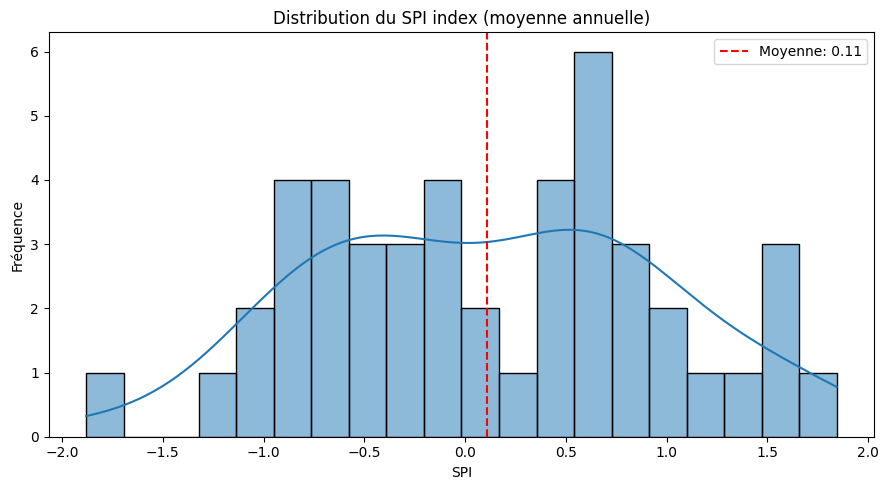

count    46.000000
mean      0.111135
std       0.856195
min      -1.880435
25%      -0.594034
50%       0.041024
75%       0.675057
max       1.844582
Name: SPI, dtype: float64


In [1787]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution du SPI index annuel
plt.figure(figsize=(9, 5))
sns.histplot(SPI_index['SPI'].dropna(), bins=20, kde=True)
plt.axvline(SPI_index['SPI'].mean(), color='red', linestyle='--', label=f"Moyenne: {SPI_index['SPI'].mean():.2f}")
plt.title('Distribution du SPI index (moyenne annuelle)')
plt.xlabel('SPI')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.show()

print(SPI_index['SPI'].describe())

On prend comme treshold -0.5 pour rester cohérent avec l'article Probabilistic estimates of drought impacts on agricultural production et puisque le premier quartile de la distribution des valeurs de l'indicateur de sécheresse est égal à -0.6, ce qui est similaire.

✔ data/spi_annuel_depuis_SPI_csv.png sauvegardé


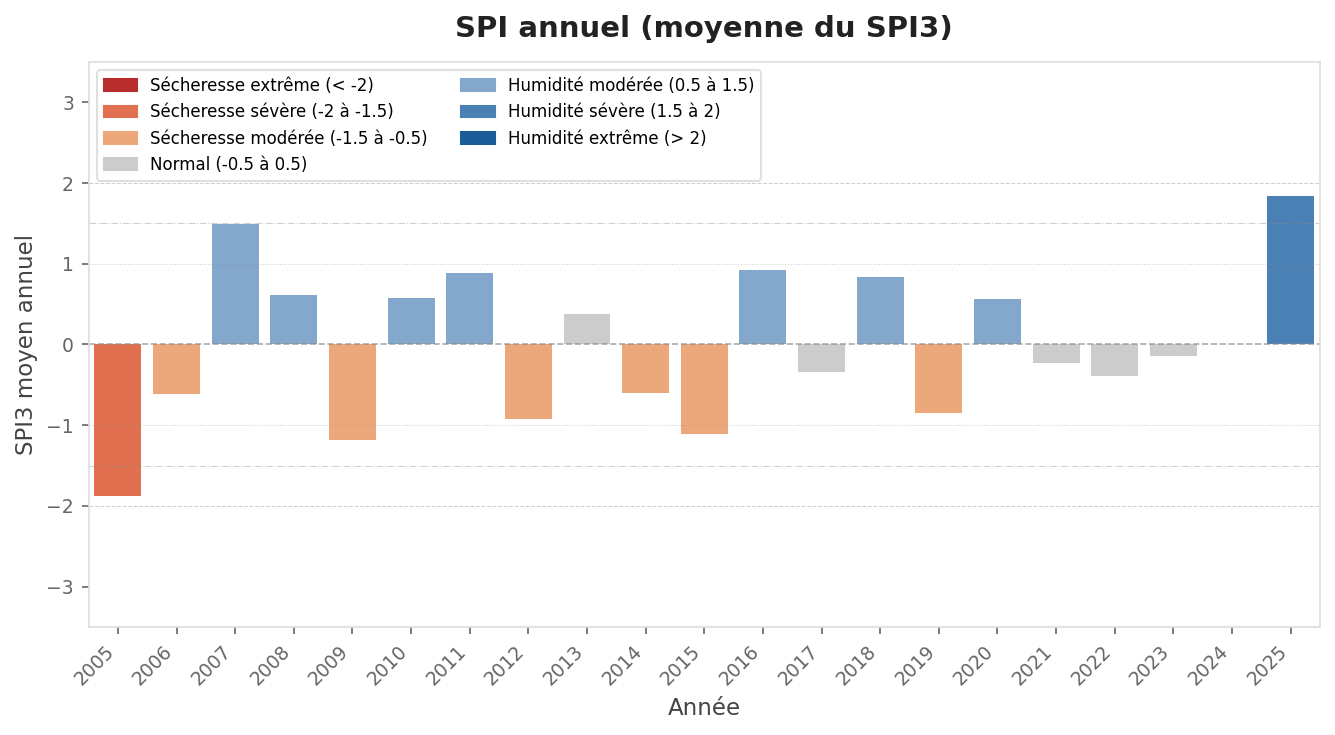


Done.
        date  spi_annuel  year
0 2005-01-01   -1.880435  2005
1 2006-01-01   -0.612123  2006
2 2007-01-01    1.496556  2007
3 2008-01-01    0.611453  2008
4 2009-01-01   -1.181186  2009


In [1788]:
"""
Visualisation du SPI annuel à partir de data/SPI.csv
Le fichier contient: time, lat, lon, SPI3 (3 mois).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# PARAMÈTRES
# ─────────────────────────────────────────────
FICHIER_SPI = "data/SPI.csv"
DPI = 150

# Catégories SPI (OMM)
BINS = [-np.inf, -2.0, -1.5, -0.5, 0.5, 1.5, 2.0, np.inf]
COLORS = ["#B72D2D", "#E07050", "#ECA87A", "#CCCCCC", "#83A8CC", "#4A80B4", "#1B5C99"]
LABELS = [
    "Sécheresse extrême (< -2)",
    "Sécheresse sévère (-2 à -1.5)",
    "Sécheresse modérée (-1.5 à -0.5)",
    "Normal (-0.5 à 0.5)",
    "Humidité modérée (0.5 à 1.5)",
    "Humidité sévère (1.5 à 2)",
    "Humidité extrême (> 2)",
]

def couleur_spi(valeur):
    for i in range(len(BINS) - 1):
        if BINS[i] <= valeur < BINS[i + 1]:
            return COLORS[i]
    return COLORS[3]

# ─────────────────────────────────────────────
# CHARGEMENT + AGRÉGATION ANNUELLE (via colonne date)
# ─────────────────────────────────────────────
df = pd.read_csv(FICHIER_SPI)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "SPI3"])
df = df[df["time"].dt.year >= 2005]

df["date"] = df["time"].dt.to_period("Y").dt.to_timestamp()

df_a = df.groupby("date", as_index=False)["SPI3"].mean()
df_a = df_a.rename(columns={"SPI3": "spi_annuel"})
df_a["year"] = df_a["date"].dt.year

# ─────────────────────────────────────────────
# FIGURE : SPI ANNUEL
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors_a = [couleur_spi(v) for v in df_a["spi_annuel"]]
ax.bar(df_a["year"], df_a["spi_annuel"], color=colors_a, width=0.8, linewidth=0)

# Ligne zéro + seuils
ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
for seuil, ls in [(-1, ":"), (-1.5, "-."), (-2, "--"), (1, ":"), (1.5, "-."), (2, "--")]:
    ax.axhline(seuil, color="#888888", linewidth=0.5, linestyle=ls, alpha=0.4)

ax.set_xlim(df_a["year"].min() - 0.5, df_a["year"].max() + 0.5)
ax.set_ylim(-3.5, 3.5)
ax.set_xticks(df_a["year"])
ax.set_xticklabels(df_a["year"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Année", fontsize=11, color="#444")
ax.set_ylabel("SPI3 moyen annuel", fontsize=11, color="#444")
ax.set_title("SPI annuel (moyenne du SPI3)", fontsize=14, fontweight="bold", pad=12, color="#222")

ax.tick_params(colors="#666", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#dddddd")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
ax.legend(
    handles=patches,
    loc="upper left",
    fontsize=8,
    framealpha=0.9,
    edgecolor="#dddddd",
    ncol=2,
)

plt.tight_layout()
plt.savefig("data/spi_annuel_depuis_SPI_csv.png", dpi=DPI, bbox_inches="tight")
print("✔ data/spi_annuel_depuis_SPI_csv.png sauvegardé")
plt.show()

print("\nDone.")
print(df_a.head())


The annual mean of SPI3 does not suggest a simple monotonic increase in drought exposure over time. Instead, it points to strong interannual variability, with alternating dry and wet years throughout the sample. Several years stand out as clearly dry, notably 2005 and then again around 2012–2015, which appears to be the most sustained relatively dry phase in the series. At the same time, this pattern is repeatedly interrupted by wetter years such as 2007, 2008, 2010, 2011, 2016, 2018, 2020, and especially 2025. Overall, the series suggests recurrent exposure to drought episodes rather than a continuous worsening trend. That said, because this indicator is based on the annual average of SPI3, it smooths short-term and seasonal extremes: a year with severe summer drought may still appear close to normal if wetter conditions prevail during the rest of the year. As a result, the figure is best interpreted as showing broad annual hydro-climatic fluctuations rather than the full intensity or persistence of drought conditions.

## Task 3

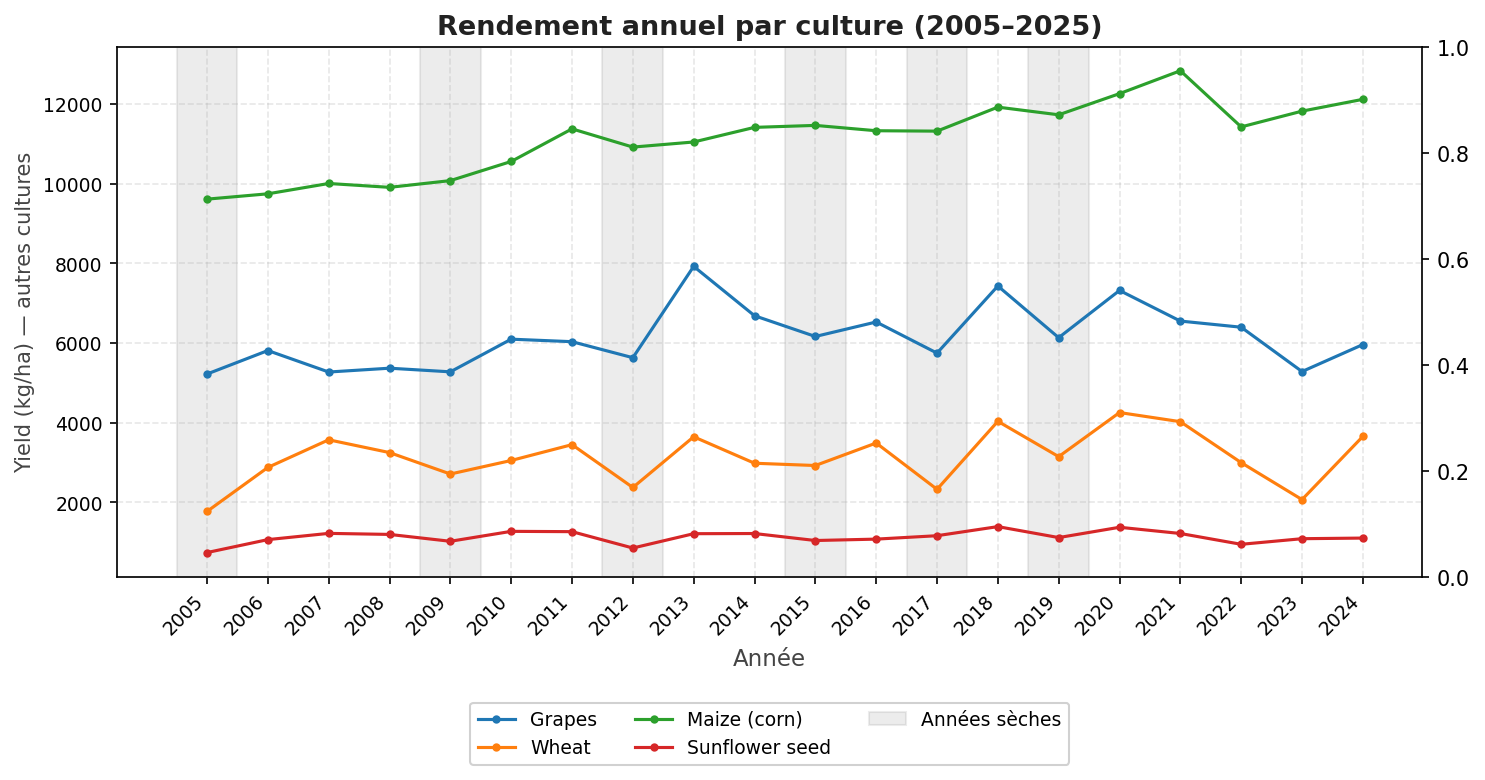

In [1789]:
crops_left = {
    "Grapes": grapes,
    "Wheat": wheat,
    "Maize (corn)": maize,
    "Sunflower seed": sunflower,
}

dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=150)
ax2 = ax1.twinx()

# Bandes grises pour années sèches (en arrière-plan)
for yr in dry_years:
    ax1.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

# Cultures sur axe gauche
for name, df_crop in crops_left.items():
    df_filtered = df_crop[df_crop["date"] >= 2005].dropna(subset=["Yield"])
    ax1.plot(df_filtered["date"], df_filtered["Yield"], marker="o", markersize=3, linewidth=1.5, label=name)


# Ticks années entières
all_years = sorted(grapes[grapes["date"] >= 2005]["date"].unique())
ax1.set_xticks(all_years)
ax1.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)

# Axes
ax1.set_xlabel("Année", fontsize=11, color="#444")
ax1.set_ylabel("Yield (kg/ha) — autres cultures", fontsize=10, color="#444")

ax1.set_title("Rendement annuel par culture (2005–2025)", fontsize=13, fontweight="bold", color="#222")

# Légende combinée — placée en dehors du graphique, en bas
dry_patch = mpatches.Patch(color="gray", alpha=0.15, label="Années sèches")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + [dry_patch], labels1 + labels2 + ["Années sèches"], fontsize=9, framealpha=0.9,
           loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)

ax1.tick_params(labelsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor("#dddddd")


# Grille légère
ax1.grid(True, alpha=0.3, linestyle='--')


plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


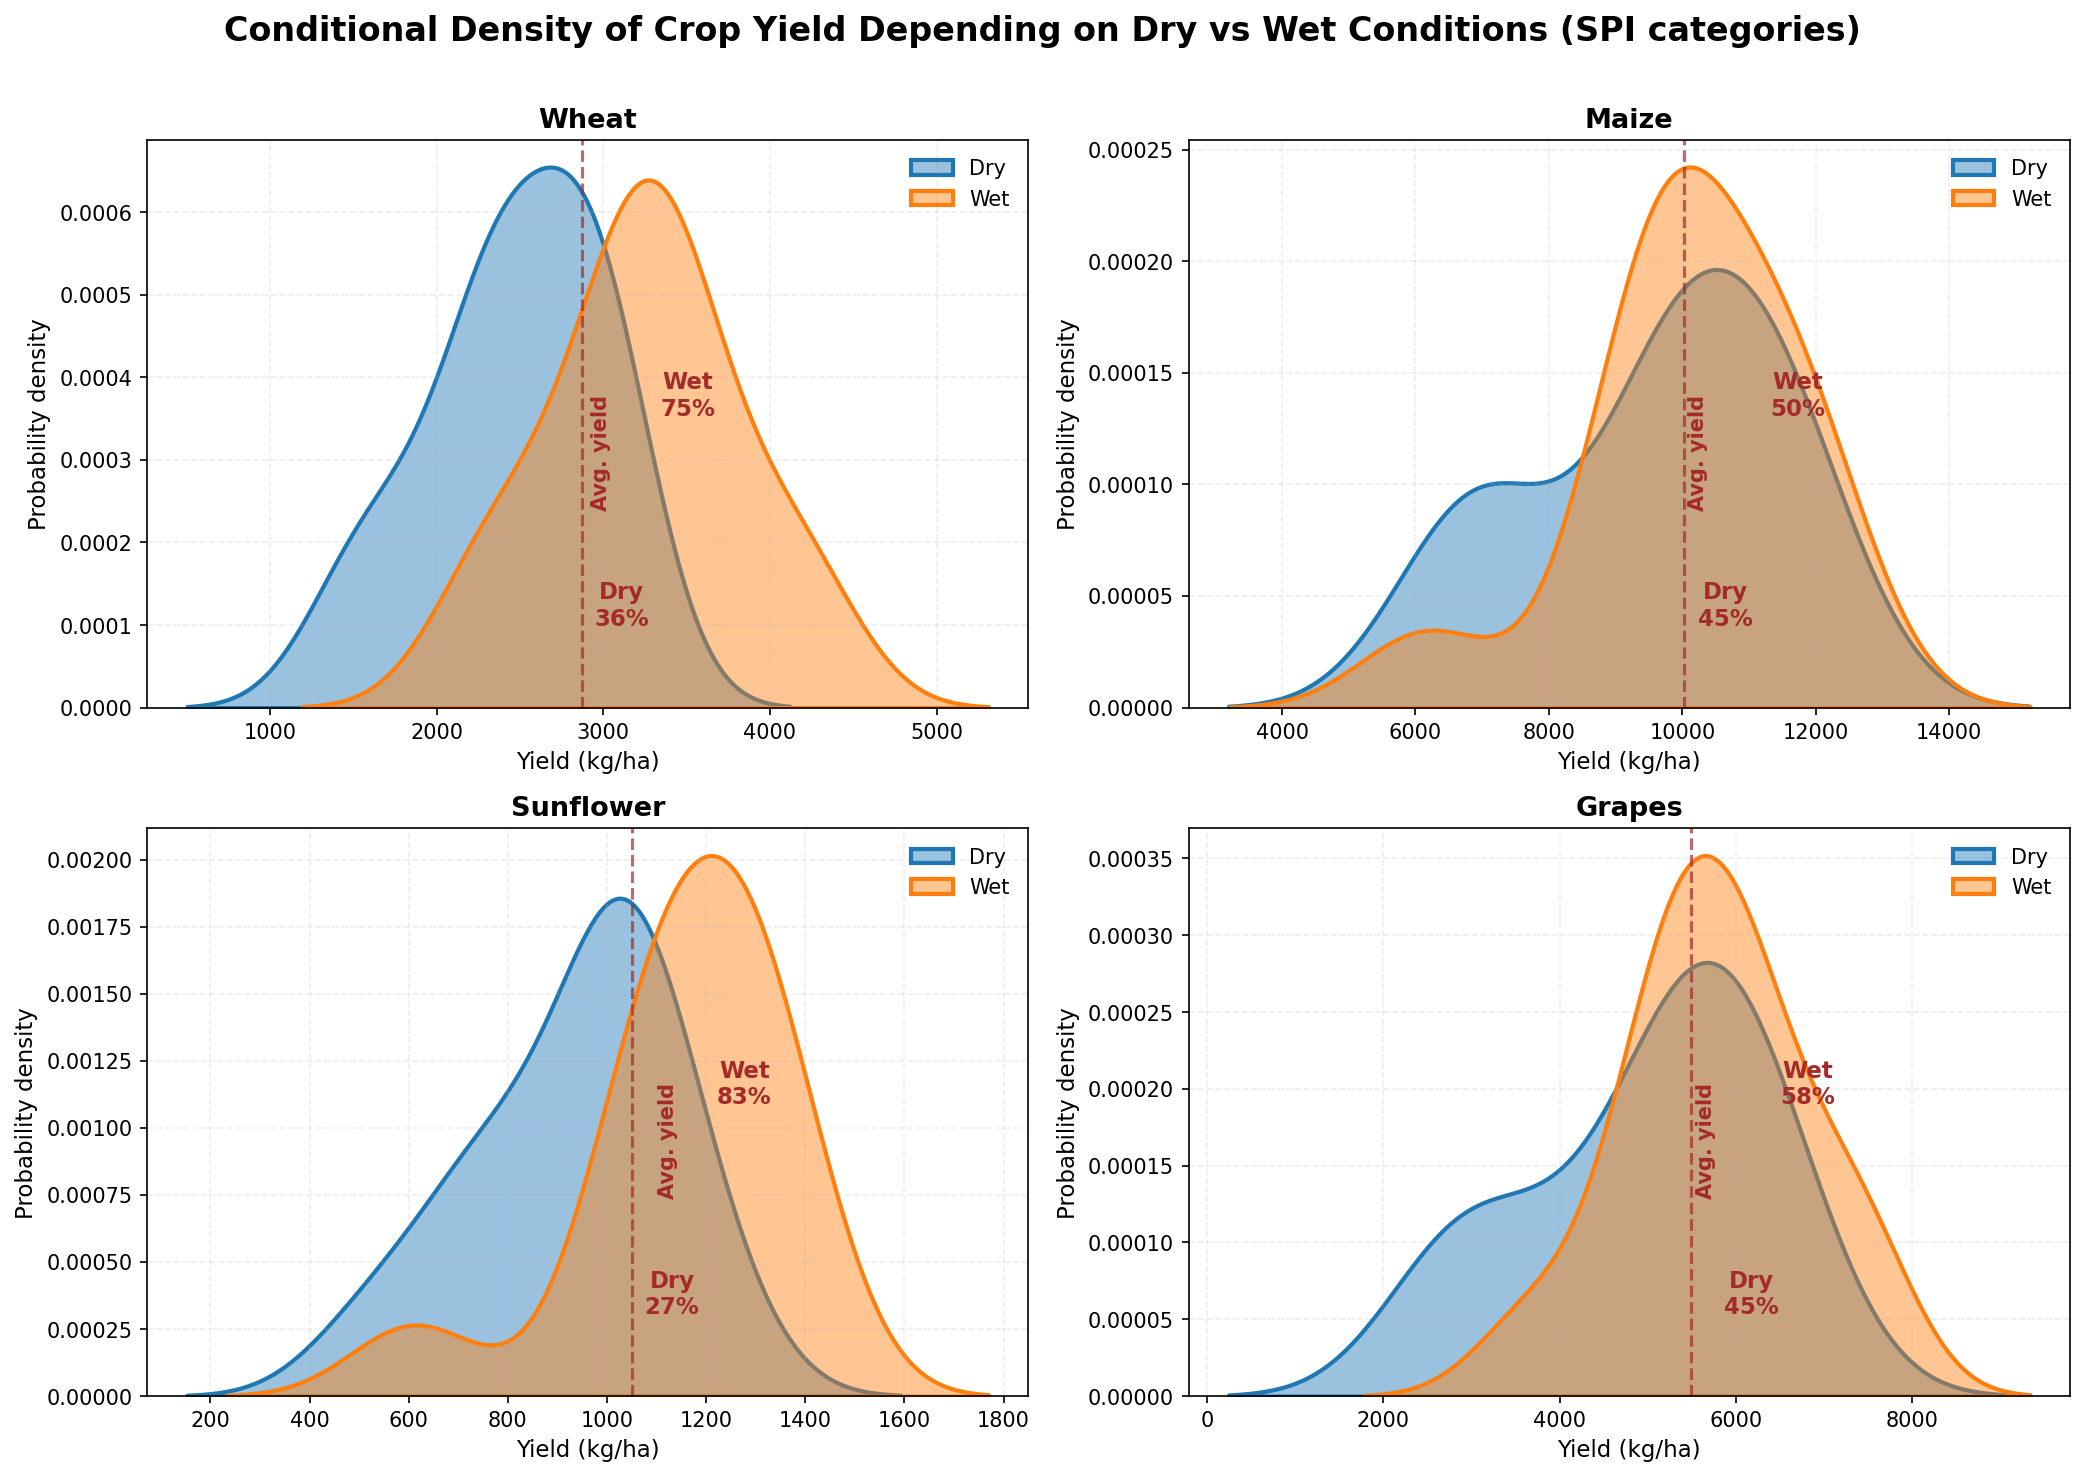

In [1790]:
SPI = SPI_index.copy()
SPI['date'] = pd.to_datetime(SPI['date']).dt.year
SPI = SPI[['date', 'SPI']].dropna().groupby('date', as_index=False)['SPI'].mean()

crops = {
    'Wheat': wheat.copy(),
    'Maize': maize.copy(),
    'Sunflower': sunflower.copy(),
    'Grapes': grapes.copy()
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
axes = axes.flatten()

for ax, (crop_name, df) in zip(axes, crops.items()):
    df = df.copy()
    df['date'] = df['date'].astype(int)

    df = df.drop(columns=['SPI'], errors='ignore')
    df = df.merge(SPI, on='date', how='left')

    df_dry = df[df['SPI'] < -0.5].copy()
    df_wet = df[df['SPI'] >= 0.5].copy()

    avg_yield = df['Yield'].mean()

    # KDE dry / wet
    sns.kdeplot(
        data=df_dry,
        x='Yield',
        label='Dry',
        fill=True,
        alpha=0.45,
        linewidth=2,
        ax=ax
    )

    sns.kdeplot(
        data=df_wet,
        x='Yield',
        label='Wet',
        fill=True,
        alpha=0.45,
        linewidth=2,
        ax=ax
    )

    # Ligne verticale moyenne
    ax.axvline(avg_yield, linestyle='--', linewidth=1.5, color='brown', alpha=0.7)


    dry_den = len(df_dry.dropna(subset=['Yield']))
    wet_den = len(df_wet.dropna(subset=['Yield']))

    dry_pct = (len(df_dry[df_dry['Yield'] > avg_yield]) / dry_den * 100) if dry_den > 0 else 0
    wet_pct = (len(df_wet[df_wet['Yield'] > avg_yield]) / wet_den * 100) if wet_den > 0 else 0


    offsets = {
        'Wheat': (650, 250),
        'Maize': (900, 1700),
        'Sunflower': (120, 70),
        'Grapes': (900, 1000)
    }

    # Texte moyenne
    ax.text(
        avg_yield + 0.01 * x_range,
        ax.get_ylim()[1] * 0.45,
        'Avg. yield',
        rotation=90,
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='brown'
    )

    # Annotations
    if len(df_dry) > 0:
        ax.text(
            df_dry['Yield'].median() + offsets[crop_name][0],
            ax.get_ylim()[1] * 0.18,
            f"Dry\n{dry_pct:.0f}%",
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='brown'
        )

    if len(df_wet) > 0:
        ax.text(
            df_wet['Yield'].median() + offsets[crop_name][1],
            ax.get_ylim()[1] * 0.55,
            f"Wet\n{wet_pct:.0f}%",
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='brown'
        )

    ax.set_title(f'{crop_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Yield (kg/ha)', fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(frameon=False)

plt.suptitle('Conditional Density of Crop Yield Depending on Dry vs Wet Conditions (SPI categories)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [1791]:
flows_returns = flows.copy()
flows_returns['Revenue'] = flows_returns['Revenue'].pct_change().dropna()*100
flows_returns['Cost'] = flows_returns['Cost'].pct_change().dropna()*100
flows_returns['Margin'] = flows_returns['Margin'].pct_change().dropna()*100
flows_returns['IPAMPA'] = flows_returns['IPAMPA'].pct_change().dropna()*100
flows_returns = flows_returns.dropna()
print(flows_returns.head(10))



    date    Revenue       Cost     IPAMPA     Margin
15  2006  17.340423   2.816901   2.816901  24.169351
16  2007  38.034660   5.603985   5.603985  50.661269
17  2008   0.483823  13.443396  13.443396  -3.052892
18  2009 -19.177506  -6.340956  -6.340956 -23.276734
19  2010  24.755633   0.554939   0.554939  34.189815
20  2011  19.194030   9.050773   9.050773  22.157071
21  2012 -12.141033   3.036437   3.036437 -16.098979
22  2013  18.070983   0.982318   0.982318  23.543688
23  2014  -2.188300  -2.431907  -2.431907  -2.124532
24  2015 -25.144486  -2.293121  -2.293121 -31.107486


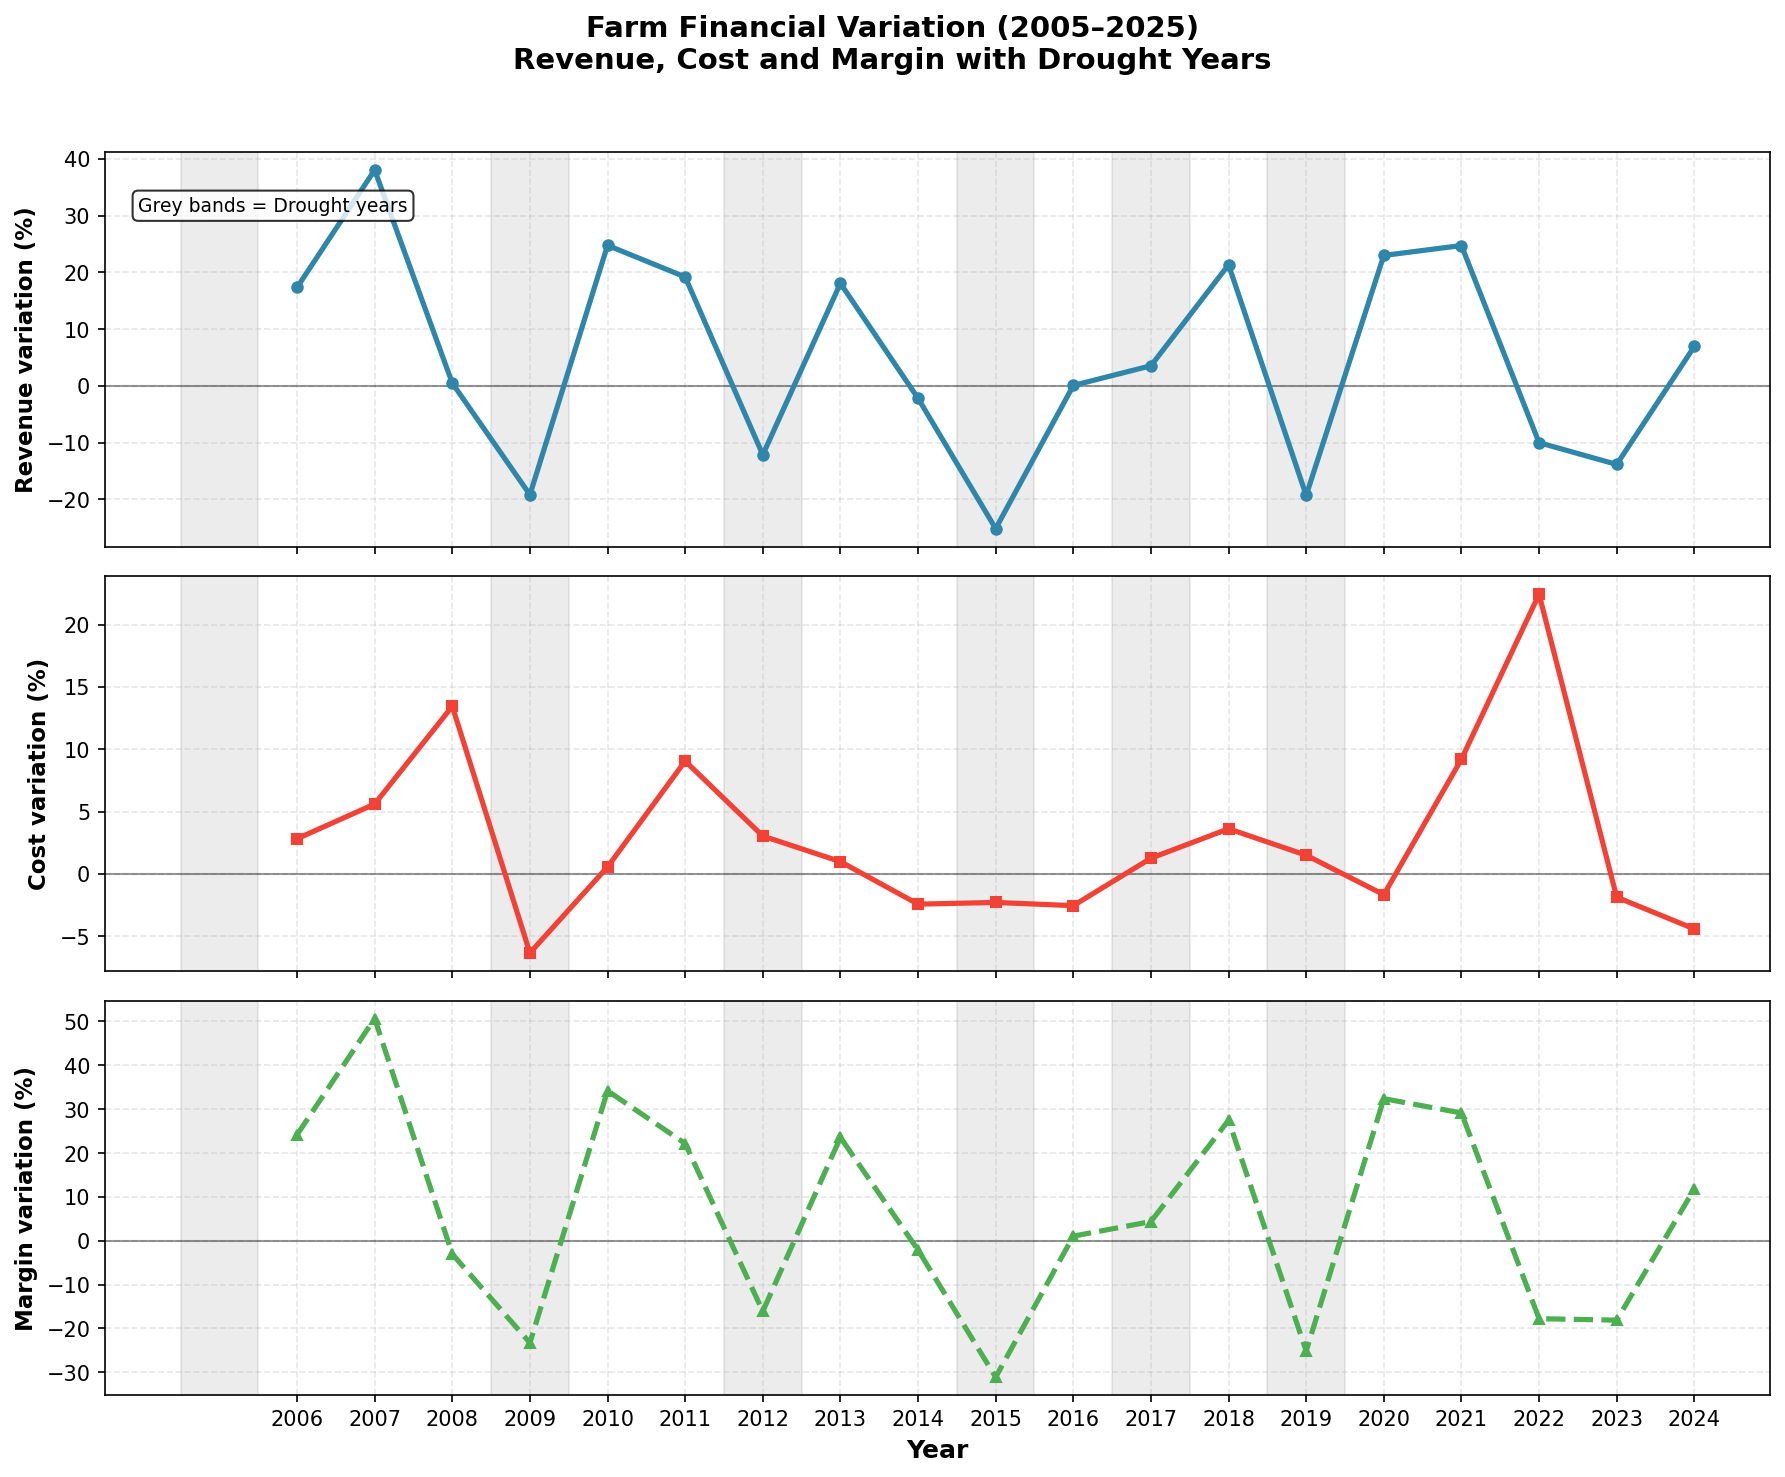

In [1792]:
dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), dpi=150, sharex=True)

# Données
flows_returns['Revenue_USD'] = flows_returns['Revenue']
flows_returns['Cost_USD'] = flows_returns['Cost']
flows_returns['Margin_USD'] = flows_returns['Margin']

titles = ['Revenue variation (%)', 'Cost variation (%)', 'Margin variation (%)']
colors = ['#2E86AB', '#F24236', '#4CAF50']
markers = ['o', 's', '^']
linestyles = ['-', '-', '--']
variables = ['Revenue_USD', 'Cost_USD', 'Margin_USD']

for ax, var, title, color, marker, ls in zip(axes, variables, titles, colors, markers, linestyles):

    # Bandes sécheresse
    for yr in dry_years:
        ax.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

    # Courbe
    ax.plot(
        flows_returns['date'],
        flows_returns[var],
        linewidth=2.5,
        marker=marker,
        markersize=5,
        linestyle=ls,
        color=color,
        zorder=3
    )

    # Ligne zéro (utile surtout pour margin)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)

    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

# Axe X commun
axes[-1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[-1].set_xticks(flows_returns['date'])
axes[-1].set_xticklabels(flows_returns['date'].astype(int))

# Titre global
fig.suptitle(
    'Farm Financial Variation (2005–2025)\nRevenue, Cost and Margin with Drought Years',
    fontsize=14,
    fontweight='bold'
)

# Annotation globale
axes[0].text(
    0.02, 0.85,
    'Grey bands = Drought years',
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Task 4